                       Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
Attribute                                                                    
Mass (10^24kg)           0.330   4.87   5.97  0.073  0.642    1898     568   
Diameter (km)             4879  12104  12756   3475   6792  142984  120536   
Density (kg/m^3)          5429   5243   5514   3340   3934    1326     687   
Gravity (m/s^2)            3.7    8.9    9.8    1.6    3.7    23.1     9.0   
Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

                       Uranus Neptune   Pluto  
Attribute                                      
Mass (10^24kg)           86.8     102  0.0130  
Diameter (km)           51118   49528    2376  
Density (kg/m^3)         1270    1638    1850  
Gravity (m/s^2)           8.7    11.0     0.7  
Escape Velocity (km/s)   21.3    23.5     1.3  
                        Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
Attribute                                

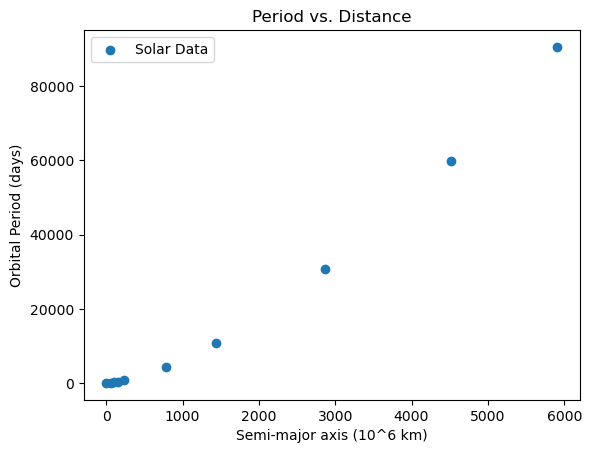

Fitted model is T = 0.20 * a^1.5


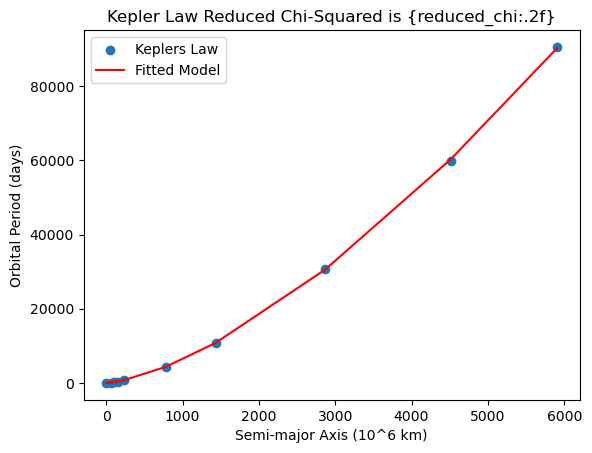

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
df = pd.read_csv('../../course_assignments/homework9/solar_system.csv', index_col = 0)
df.shape # the shape of the dataset is (20, 11)
# there are 20 rows and 11 columns
print(df.head())
print(df.tail())
print(df.columns)
print(df.iloc[:, 0])
orbital_period = df.iloc[10].astype('float')
perihelion = df.iloc[8].astype('float')
aphelion = df.iloc[9].astype('float')
#perihelion is the point in an orbit where an object is closest to the sun while aphelion is the point there it is farthest away.
#semi major axis is half of the longest diameter of an ellipse.
semi_major_axis = (perihelion + aphelion) / 2
new_row = pd.Series(semi_major_axis, name='Semi-major axis (km)')
df = pd.concat([df, new_row.to_frame().T])
df.shape # the shape of the dataset is now (21, 11). there are 21 rows and 11 columns.
plt.scatter(semi_major_axis, orbital_period, label='Solar Data')
plt.xlabel('Semi-major axis (10^6 km)')
plt.ylabel('Orbital Period (days)')
plt.title("Period vs. Distance")
plt.legend()
plt.show()
def keplers_third_law(a, m):
    return m * a ** 1.5
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)
m_fit = popt[0]
print(f"Fitted model is T = {m_fit:.2f} * a^1.5")
y = keplers_third_law(semi_major_axis, m_fit)
residuals = orbital_period - y
chisq = np.sum(residuals**2)
dof = len(semi_major_axis) - 1
chisq_reduced = chisq / dof
plt.figure()
plt.scatter(semi_major_axis, orbital_period, label='Keplers Law')
y_fit = keplers_third_law(semi_major_axis, m_fit)
plt.plot(semi_major_axis, y_fit, color='red', label="Fitted Model")
plt.title("Kepler Law Reduced Chi-Squared is {reduced_chi:.2f}")
plt.xlabel("Semi-major Axis (10^6 km)")
plt.ylabel("Orbital Period (days)")
plt.legend()
plt.show()
df.to_csv("kepler.csv", index=False)